# Parallelisation Pattern

**Pattern**: Break a task into multiple subtasks executed in parallel, merge results.

**Example**: E-commerce Order Checkout

**Workflow**:
```
                                    ┌→ [Calculate Price]  ─┐
START → [Validate Order] → [Check Stock] →                  → [Generate Summary] → END
                                    └→ [Calculate Delivery]─┘
```

**Key insight**: Price and delivery are calculated ONLY for in-stock items.
- First: validate order items exist in catalog
- Then: check stock (must complete before price/delivery)
- Parallel: calculate price AND delivery for in-stock items
- Finally: generate summary

## Setup

In [41]:
import os
from typing import TypedDict, Annotated
from operator import add

from langgraph.graph import StateGraph, START, END

## Product Catalog

In [42]:
# Product catalog with price, discount, delivery time, and stock status
CATALOG = { 
    "apple_watch": {"price": 50000, "discount": 0.1, "delivery_days": 5, "in_stock": True},
    "iphone": {"price": 100000, "discount": 0.05, "delivery_days": 3, "in_stock": True},
    "macbook": {"price": 150000, "discount": 0.15, "delivery_days": 7, "in_stock": False},
    "airpods": {"price": 20000, "discount": 0.0, "delivery_days": 2, "in_stock": True},
    "ipad": {"price": 80000, "discount": 0.1, "delivery_days": 4, "in_stock": True},
}

## Define State

Using `Annotated` with `add` reducer for `errors` field so parallel nodes can all append errors without overwriting each other.

In [43]:
class OrderState(TypedDict):
    # Input
    requested_items: list[str]
    
    # After validation
    valid_items: list[str]
    invalid_items: list[str]
    
    # After stock check
    in_stock_items: list[str]
    out_of_stock_items: list[str]
    
    # Parallel node outputs (only for in-stock items)
    total_price: float
    total_discount: float
    price_breakdown: dict       # item -> {original, discount, final}
    
    delivery_days: int
    delivery_breakdown: dict    # item -> days
    
    # Final output
    order_summary: str
    errors: Annotated[list[str], add]  # Reducer: append errors from all nodes

## Define Nodes

In [44]:
def validate_order(state: OrderState) -> dict:
    """Validate requested items exist in catalog."""
    requested = state["requested_items"]
    
    valid_items = []
    invalid_items = []
    errors = []
    
    for item in requested:
        if item in CATALOG:
            valid_items.append(item)
        else:
            invalid_items.append(item)
            errors.append(f"Item '{item}' not found in catalog")
    
    return {
        "valid_items": valid_items,
        "invalid_items": invalid_items,
        "errors": errors
    }

In [45]:
def check_stock(state: OrderState) -> dict:
    """Check stock availability for all valid items."""
    valid_items = state["valid_items"]
    
    in_stock = []
    out_of_stock = []
    errors = []
    
    for item in valid_items:
        if CATALOG[item]["in_stock"]:
            in_stock.append(item)
        else:
            out_of_stock.append(item)
            errors.append(f"Item '{item}' is out of stock")
    
    return {
        "in_stock_items": in_stock,
        "out_of_stock_items": out_of_stock,
        "errors": errors
    }

In [46]:
def calculate_price(state: OrderState) -> dict:
    """Calculate total price with discounts for IN-STOCK items only."""
    in_stock_items = state["in_stock_items"]  # Only in-stock items!
    
    total_price = 0
    total_discount = 0
    price_breakdown = {}
    
    for item in in_stock_items:
        original = CATALOG[item]["price"]
        discount_pct = CATALOG[item]["discount"]
        discount_amt = original * discount_pct
        final = original - discount_amt
        
        price_breakdown[item] = {
            "original": original,
            "discount_pct": f"{int(discount_pct * 100)}%",
            "discount_amt": discount_amt,
            "final": final
        }
        
        total_price += final
        total_discount += discount_amt
    
    return {
        "total_price": total_price,
        "total_discount": total_discount,
        "price_breakdown": price_breakdown,
        "errors": []  # No errors from this node
    }

In [47]:
def calculate_delivery(state: OrderState) -> dict:
    """Calculate delivery time for IN-STOCK items only (max of all items)."""
    in_stock_items = state["in_stock_items"]  # Only in-stock items!
    
    delivery_breakdown = {}
    max_days = 0
    
    for item in in_stock_items:
        days = CATALOG[item]["delivery_days"]
        delivery_breakdown[item] = days
        max_days = max(max_days, days)
    
    return {
        "delivery_days": max_days,
        "delivery_breakdown": delivery_breakdown,
        "errors": []  # No errors from this node
    }

In [48]:
def generate_summary(state: OrderState) -> dict:
    """Generate final order summary message."""
    
    lines = []
    lines.append("=" * 50)
    lines.append("           ORDER SUMMARY")
    lines.append("=" * 50)
    
    # Requested items
    lines.append(f"\nRequested Items: {', '.join(state['requested_items']) if state['requested_items'] else 'None'}")
    
    # Invalid items (if any)
    if state.get("invalid_items"):
        lines.append(f"\n[WARNING] Invalid Items: {', '.join(state['invalid_items'])}")
    
    # Out of stock items (if any)
    if state.get("out_of_stock_items"):
        lines.append(f"\n[X] Out of Stock: {', '.join(state['out_of_stock_items'])}")
    
    # In stock items
    in_stock = state.get("in_stock_items", [])
    if in_stock:
        lines.append(f"\n[OK] Items to Ship: {', '.join(in_stock)}")
        
        # Price breakdown
        lines.append("\n" + "-" * 50)
        lines.append("PRICE BREAKDOWN (In-Stock Items Only)")
        lines.append("-" * 50)
        
        price_breakdown = state.get("price_breakdown", {})
        for item in in_stock:
            if item in price_breakdown:
                p = price_breakdown[item]
                lines.append(f"  {item}:")
                lines.append(f"    Original: ₹{p['original']:,.0f}")
                lines.append(f"    Discount: {p['discount_pct']} (-₹{p['discount_amt']:,.0f})")
                lines.append(f"    Final:    ₹{p['final']:,.0f}")
        
        lines.append("\n" + "-" * 50)
        lines.append(f"Total Discount: ₹{state.get('total_discount', 0):,.0f}")
        lines.append(f"TOTAL PRICE:    ₹{state.get('total_price', 0):,.0f}")
        lines.append("-" * 50)
        
        # Delivery info
        lines.append(f"\n[DELIVERY] Estimated Delivery: {state.get('delivery_days', 'N/A')} days")
        
        delivery_breakdown = state.get("delivery_breakdown", {})
        for item in in_stock:
            if item in delivery_breakdown:
                lines.append(f"   - {item}: {delivery_breakdown[item]} days")
    else:
        lines.append("\n[X] No items available to ship.")
    
    # Errors summary
    errors = state.get("errors", [])
    if errors:
        lines.append("\n" + "-" * 50)
        lines.append("WARNINGS/ERRORS")
        lines.append("-" * 50)
        for error in errors:
            lines.append(f"  • {error}")
    
    lines.append("\n" + "=" * 50)
    
    return {"order_summary": "\n".join(lines)}

## Build the Graph

**Correct flow**: Stock check must complete BEFORE price/delivery calculation.

```
START → validate_order → check_stock → [calculate_price, calculate_delivery] → generate_summary → END
```

Only `calculate_price` and `calculate_delivery` run in **parallel** (both need `in_stock_items`).

In [49]:
# Create graph
graph = StateGraph(OrderState)

# Add nodes
graph.add_node("validate_order", validate_order)
graph.add_node("check_stock", check_stock)
graph.add_node("calculate_price", calculate_price)
graph.add_node("calculate_delivery", calculate_delivery)
graph.add_node("generate_summary", generate_summary)

# Add edges
graph.add_edge(START, "validate_order")
graph.add_edge("validate_order", "check_stock")  # Sequential: must check stock first

# Fan-out: check_stock → 2 parallel nodes (price & delivery)
graph.add_edge("check_stock", "calculate_price")
graph.add_edge("check_stock", "calculate_delivery")

# Fan-in: 2 parallel nodes → generate_summary
graph.add_edge("calculate_price", "generate_summary")
graph.add_edge("calculate_delivery", "generate_summary")

graph.add_edge("generate_summary", END)

# Compile
app = graph.compile()

## Visualize the Graph

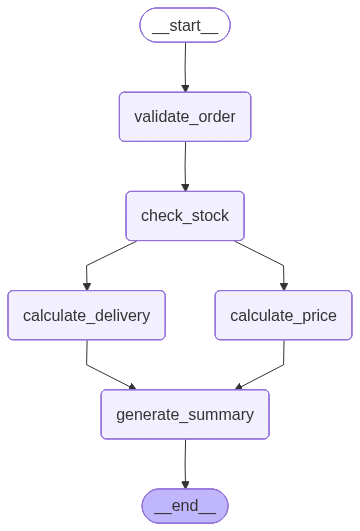

In [50]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Test Case 1: All Items Valid and In Stock

In [51]:
result = app.invoke({
    "requested_items": ["iphone", "airpods"],
    "errors": []  # Initialize empty list for reducer
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: iphone, airpods

[OK] Items to Ship: iphone, airpods

--------------------------------------------------
PRICE BREAKDOWN (In-Stock Items Only)
--------------------------------------------------
  iphone:
    Original: ₹100,000
    Discount: 5% (-₹5,000)
    Final:    ₹95,000
  airpods:
    Original: ₹20,000
    Discount: 0% (-₹0)
    Final:    ₹20,000

--------------------------------------------------
Total Discount: ₹5,000
TOTAL PRICE:    ₹115,000
--------------------------------------------------

[DELIVERY] Estimated Delivery: 3 days
   - iphone: 3 days
   - airpods: 2 days



## Test Case 2: Some Items Out of Stock

**Expected**: macbook is out of stock, so price/delivery calculated only for iphone and airpods.

In [52]:
result = app.invoke({
    "requested_items": ["iphone", "macbook", "airpods"],  # macbook is out of stock
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: iphone, macbook, airpods

[X] Out of Stock: macbook

[OK] Items to Ship: iphone, airpods

--------------------------------------------------
PRICE BREAKDOWN (In-Stock Items Only)
--------------------------------------------------
  iphone:
    Original: ₹100,000
    Discount: 5% (-₹5,000)
    Final:    ₹95,000
  airpods:
    Original: ₹20,000
    Discount: 0% (-₹0)
    Final:    ₹20,000

--------------------------------------------------
Total Discount: ₹5,000
TOTAL PRICE:    ₹115,000
--------------------------------------------------

[DELIVERY] Estimated Delivery: 3 days
   - iphone: 3 days
   - airpods: 2 days

--------------------------------------------------
WARNINGS/ERRORS
--------------------------------------------------
  • Item 'macbook' is out of stock



## Test Case 3: Invalid Items in Order

In [53]:
result = app.invoke({
    "requested_items": ["iphone", "samsung_galaxy", "airpods"],  # samsung_galaxy doesn't exist
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: iphone, samsung_galaxy, airpods

[WARNING] Invalid Items: samsung_galaxy

[OK] Items to Ship: iphone, airpods

--------------------------------------------------
PRICE BREAKDOWN (In-Stock Items Only)
--------------------------------------------------
  iphone:
    Original: ₹100,000
    Discount: 5% (-₹5,000)
    Final:    ₹95,000
  airpods:
    Original: ₹20,000
    Discount: 0% (-₹0)
    Final:    ₹20,000

--------------------------------------------------
Total Discount: ₹5,000
TOTAL PRICE:    ₹115,000
--------------------------------------------------

[DELIVERY] Estimated Delivery: 3 days
   - iphone: 3 days
   - airpods: 2 days

--------------------------------------------------
WARNINGS/ERRORS
--------------------------------------------------
  • Item 'samsung_galaxy' not found in catalog



## Test Case 4: Mixed - Invalid + Out of Stock

**Expected**: Only iphone and ipad are valid AND in stock.

In [54]:
result = app.invoke({
    "requested_items": ["iphone", "macbook", "pixel_phone", "ipad"],  # macbook out of stock, pixel doesn't exist
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: iphone, macbook, pixel_phone, ipad

[WARNING] Invalid Items: pixel_phone

[X] Out of Stock: macbook

[OK] Items to Ship: iphone, ipad

--------------------------------------------------
PRICE BREAKDOWN (In-Stock Items Only)
--------------------------------------------------
  iphone:
    Original: ₹100,000
    Discount: 5% (-₹5,000)
    Final:    ₹95,000
  ipad:
    Original: ₹80,000
    Discount: 10% (-₹8,000)
    Final:    ₹72,000

--------------------------------------------------
Total Discount: ₹13,000
TOTAL PRICE:    ₹167,000
--------------------------------------------------

[DELIVERY] Estimated Delivery: 4 days
   - iphone: 3 days
   - ipad: 4 days

--------------------------------------------------
WARNINGS/ERRORS
--------------------------------------------------
  • Item 'pixel_phone' not found in catalog
  • Item 'macbook' is out of stock



## Test Case 5: All Items Out of Stock

In [55]:
result = app.invoke({
    "requested_items": ["macbook"],  # Only macbook, which is out of stock
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: macbook

[X] Out of Stock: macbook

[X] No items available to ship.

--------------------------------------------------
WARNINGS/ERRORS
--------------------------------------------------
  • Item 'macbook' is out of stock



## Test Case 6: All Items Invalid

In [56]:
result = app.invoke({
    "requested_items": ["nokia", "samsung"],  # Neither exists
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: nokia, samsung

[WARNING] Invalid Items: nokia, samsung

[X] No items available to ship.

--------------------------------------------------
WARNINGS/ERRORS
--------------------------------------------------
  • Item 'nokia' not found in catalog
  • Item 'samsung' not found in catalog



## Test Case 7: Empty Order

In [57]:
result = app.invoke({
    "requested_items": [],
    "errors": []
})

print(result["order_summary"])

           ORDER SUMMARY

Requested Items: None

[X] No items available to ship.



## Stream Execution (See Node Order)

In [58]:
print("Streaming execution...\n")

for step in app.stream({"requested_items": ["apple_watch", "macbook", "iphone"], "errors": []}):
    for node_name, output in step.items():
        print(f"[DONE] Node completed: {node_name}")
        
        # Show key outputs
        if node_name == "check_stock":
            print(f"   In stock: {output.get('in_stock_items', [])}")
            print(f"   Out of stock: {output.get('out_of_stock_items', [])}")
        elif node_name == "calculate_price":
            print(f"   Total price: ₹{output.get('total_price', 0):,.0f}")
        elif node_name == "calculate_delivery":
            print(f"   Delivery days: {output.get('delivery_days', 0)}")

print("\n" + "=" * 50)
print("Final Summary:")
print(result["order_summary"])

Streaming execution...

[DONE] Node completed: validate_order
[DONE] Node completed: check_stock
   In stock: ['apple_watch', 'iphone']
   Out of stock: ['macbook']
[DONE] Node completed: calculate_delivery
   Delivery days: 5
[DONE] Node completed: calculate_price
   Total price: ₹140,000
[DONE] Node completed: generate_summary

Final Summary:
           ORDER SUMMARY

Requested Items: None

[X] No items available to ship.



## Key Takeaways

1. **Sequential then Parallel**: `check_stock` must complete BEFORE `calculate_price` and `calculate_delivery`
2. **Data dependency**: Price/delivery nodes read `in_stock_items`, not `valid_items`
3. **Reducers** (`Annotated[list, add]`) let parallel nodes write to `errors` without overwriting
4. **Fan-out/Fan-in**: Only parallelize nodes that are truly independent
5. **Edge cases**: Handle invalid items, out of stock, empty orders gracefully

s